In [10]:
%%capture
# !pip install pandas matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Enable inline plotting
%matplotlib inline

# --------------------------------------------
# 1. Global Constants & Configurations
# --------------------------------------------

# Define the country mapping for proper naming
country_mapping = {
    'unitedstates': 'United States',
    'australia': 'Australia',
    'southafrica': 'South Africa',
    'canada': 'Canada',
    'india': 'India',
    'brazil': 'Brazil',
    'southkorea': 'South Korea',
    'singapore': 'Singapore',
    'germany': 'Germany',
    'spain': 'Spain'
}

# Set a professional-looking style globally
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'grid.linestyle': '--',
    'grid.alpha': 0.6
})

# --------------------------------------------
# 2. Load Datasets
# --------------------------------------------

def load_data(combined_csv_path, error_csv_path):
    """Loads the main dataset and error count dataset."""
    df = pd.read_csv(combined_csv_path)

    error_df = pd.read_csv(error_csv_path)
    error_df['Country'] = error_df['Country'].astype(str).str.lower().str.strip()

    return df, error_df

# --------------------------------------------
# 3. Compute Valid & Normalized Entries
# --------------------------------------------

def compute_valid_entries(df):
    """
    Computes valid entries for each country.
    - United States: All entries are valid.
    - Other countries: Count only country-specific entries.
    """
    results = []
    for country, group in df.groupby('country'):
        if country.lower() == 'unitedstates':
            valid_count = len(group)
        else:
            valid_count = group['countrySpecificEntries'].sum()
        results.append((country.capitalize(), valid_count))

    return pd.DataFrame(results, columns=['Country', 'Valid Entries']).sort_values('Valid Entries', ascending=False)

def compute_normalized_entries(results_df, error_df):
    """
    Computes the normalized valid entries using error counts.
    Formula: Normalized = (Valid / (525 - Error Count)) * 525
    """
    error_counts = dict(zip(error_df['Country'], error_df['Error Count']))

    def normalize(row):
        error_count = error_counts.get(row['Country'].lower(), 0)
        success_sites = 525 - error_count
        return 0 if success_sites == 0 else int(round((row['Valid Entries'] / success_sites) * 525, 0))

    results_df['Valid Normalized Entries'] = results_df.apply(normalize, axis=1)
    return results_df

# --------------------------------------------
# 4. Plot Bar Chart
# --------------------------------------------

def plot_bar_chart(df, title, ylabel, color='#0072B2'):
    """
    Plots a bar chart with consistent formatting.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(df['Country'], df['Valid Normalized Entries'], color=color)

    ax.set_xticks(range(len(df['Country'])))
    ax.set_xticklabels(df['Country'], rotation=45, ha='right', fontsize=12)

    ax.set_xlabel('Country', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')

    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    ax.xaxis.grid(False)

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.tight_layout()
    plt.show()

# Main Part: Apply the functions   
# --------------------------------------------
# 1. Load Data
# --------------------------------------------
combined_csv_path = "../analysis_data/entries/combined_all_countries.csv"
error_csv_path = "Error_Analysis/country_specific_error_count.csv"

df, error_df = load_data(combined_csv_path, error_csv_path)

# --------------------------------------------
# 2. Compute Valid & Normalized Entries
# --------------------------------------------
results_df = compute_valid_entries(df)
results_df = compute_normalized_entries(results_df, error_df)

# Apply country name mapping for better readability
results_df['Country'] = results_df['Country'].str.lower().map(country_mapping).fillna(results_df['Country'].str.capitalize())

# --------------------------------------------
# 3. Display Results Table
# --------------------------------------------
print("=== Total Valid Entries For Countries 525 Websites ===")
display(results_df)

# --------------------------------------------
# 4. Plot the Normalized Results
# --------------------------------------------
plot_bar_chart(results_df, 
               title='Total Valid Normalized Entries For Countries 525 Websites', 
               ylabel='Valid Normalized Entries')


FileNotFoundError: [Errno 2] No such file or directory: '../Error_Analysis/country_specific_error_count.csv'

{'unitedstates': 49, 'singapore': 42, 'india': 36, 'germany': 26, 'spain': 26, 'southafrica': 22, 'southkorea': 22, 'australia': 21, 'brazil': 17, 'canada': 5}


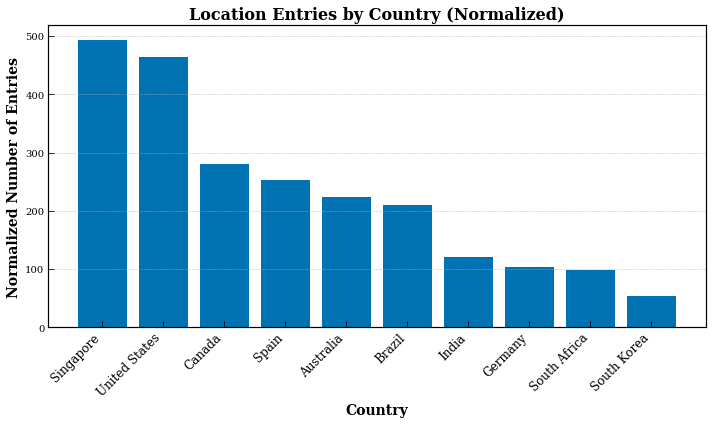

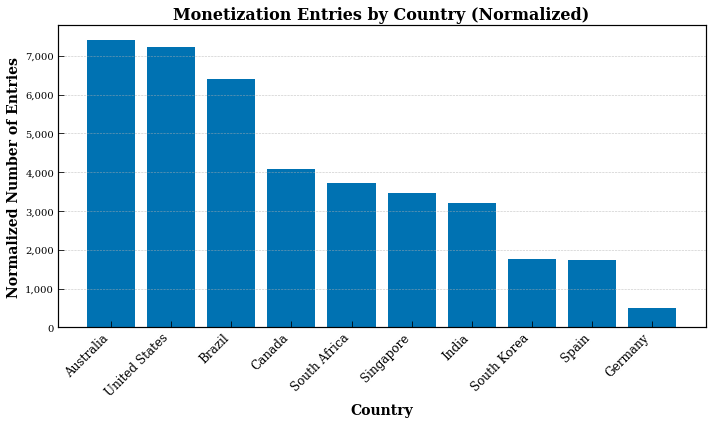

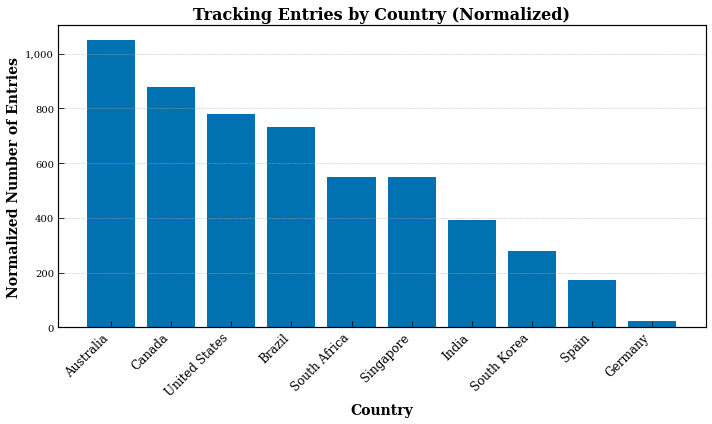

In [ ]:
# --------------------------------------------
# 1. Define Permission Types and Load Error Counts
# --------------------------------------------
permission_types = ['location', 'monetization', 'tracking']

# Load the error counts to compute the total success websites per country.
error_count_df = pd.read_csv("Error_Analysis/country_specific_error_count.csv") 
error_count_df['Country'] = error_count_df['Country'].astype(str).str.lower().str.strip()

# Build a dictionary mapping country (lowercase) to its error count.
error_counts = dict(zip(error_count_df['Country'], error_count_df['Error Count']))
print (error_counts)

# --------------------------------------------
# 2. Create a Valid-Entry Flag in the Main DataFrame
# --------------------------------------------
df['valid_entry'] = df.apply(
    lambda row: True if row['country'].lower() == 'unitedstates' 
                else row['countrySpecificEntries'],
    axis=1
)
df_valid = df[df['valid_entry']]

# --------------------------------------------
# 3. Process Each Permission Type Using Normalized Data and Plot Using Global Function
# --------------------------------------------
for p_type in permission_types:
    # Filter valid data for this permission type.
    subset = df_valid[df_valid['permission'] == p_type]
    
    # Group by country and count the raw number of entries.
    grouped = subset.groupby('country').size().reset_index(name='Count')
    
    # Compute normalized count for each country.
    def compute_normalized(row):
        country_lower = row['country'].lower().strip()
        error_count = error_counts.get(country_lower, 0)
        success_sites = 525 - error_count  # Total success websites for the country.
        return 0 if success_sites == 0 else (row['Count'] / success_sites) * 525
    
    grouped['Normalized Count'] = grouped.apply(compute_normalized, axis=1)
    grouped = grouped.sort_values('Normalized Count', ascending=False)
    
    # Rename columns to match the global plotting function.
    df_plot = grouped.rename(columns={'country': 'Country', 'Normalized Count': 'Valid Normalized Entries'})
    
    # Map country names using the global country_mapping.
    df_plot['Country'] = df_plot['Country'].str.lower().map(country_mapping).fillna(
        df_plot['Country'].str.capitalize())
    
    # Plot using the global plot_bar_chart function.
    plot_bar_chart(df_plot, 
                   title=f'{p_type.capitalize()} Entries by Country (Normalized)', 
                   ylabel='Normalized Number of Entries', 
                   )


0. Stacked bar for All Entries

1998

South Korea protocol comparison (average rows per site)
-------------------------------------------------------
HTTPS → rows: 1,906  sites: 327  average ≈ 5.8
HTTP  → rows: 92   sites: 16   average ≈ 5.8
Australia → australia error_count: 21 success_sites: 504
Brazil → brazil error_count: 17 success_sites: 508
Canada → canada error_count: 5 success_sites: 520
Germany → germany error_count: 26 success_sites: 499
India → india error_count: 36 success_sites: 489
Singapore → singapore error_count: 42 success_sites: 483
South Africa → southafrica error_count: 22 success_sites: 503
South Korea → southkorea error_count: 22 success_sites: 503
Spain → spain error_count: 26 success_sites: 499
United States → unitedstates error_count: 49 success_sites: 476


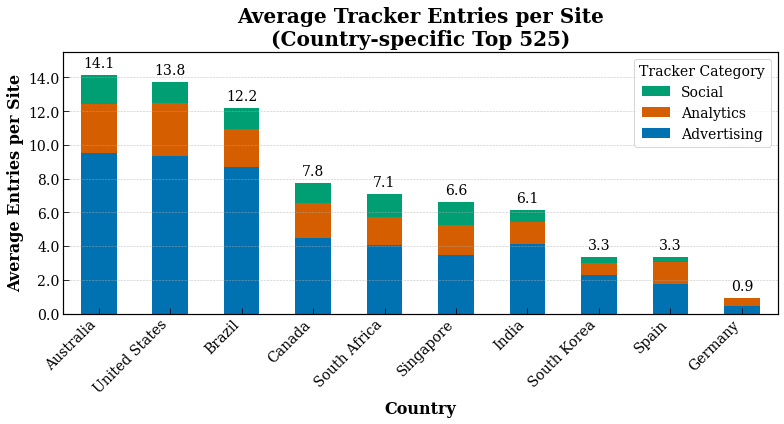

In [ ]:
import matplotlib.ticker as ticker

import re

def normalize_series(row):
    """
    Given a row (with the country as the index), look up its error count
    (using a key like 'unitedstates'), compute success_sites = 525 - error_count,
    and return the average entries per site.
    """
    display_name = row.name
    # turn "United states" → "unitedstates"
    norm_key = re.sub(r'\W+', '', str(display_name).lower())
    error_count = error_counts.get(norm_key, 0)
    success_sites = 525 - error_count
    print(display_name, "→", norm_key, "error_count:", error_count, "success_sites:", success_sites)
    if success_sites == 0:
        return row * 0
    return row / success_sites


# ==============================================================  
#  South Korea HTTPS vs HTTP – unique rootUrls, row counts, averages  
# ==============================================================  

sk_key = 'southkorea'
df_sk = df_valid[df_valid['country'].str.lower().str.strip() == sk_key]
print(len(df_sk))
# split by protocol
df_sk_https = df_sk[df_sk['rootUrl'].str.startswith('https://', na=False)]
df_sk_http  = df_sk[df_sk['rootUrl'].str.startswith('http://',  na=False) &
                    ~df_sk['rootUrl'].str.startswith('https://', na=False)]

# basic counts
https_sites = df_sk_https['rootUrl'].nunique()
http_sites  = df_sk_http ['rootUrl'].nunique()
https_rows  = len(df_sk_https)
http_rows   = len(df_sk_http)

# compute average rows per site (one decimal)
avg_https = (https_rows / https_sites) if https_sites else 0
avg_http  = (http_rows  / http_sites ) if http_sites  else 0

print('\nSouth Korea protocol comparison (average rows per site)')
print('-------------------------------------------------------')
print(f'HTTPS → rows: {https_rows:,}  sites: {https_sites:,}  average ≈ {avg_https:.1f}')
print(f'HTTP  → rows: {http_rows:,}   sites: {http_sites:,}   average ≈ {avg_http:.1f}')
# ===============================
#  Stacked Bar Chart – Monetization Sub-types (averages)
# ===============================
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

desired_order_mon = ['Advertising', 'Analytics', 'Social']
colour_map = {'Advertising': '#0072B2',
              'Analytics'  : '#D55E00',
              'Social'     : '#009E73'}

# ── 1. Monetization rows only ──────────────────────────────────────────
df_monet = df_valid[df_valid['permission'] == 'monetization']

# ── 2. Pivot: rows = country, cols = typ ───────────────────────────────
df_stacked = (
    df_monet
      .groupby(['country', 'typ'])
      .size()
      .unstack(fill_value=0)
)

# ── 3. Harmonise column names & enforce display order ──────────────────
df_stacked.columns = df_stacked.columns.str.capitalize()
df_stacked = df_stacked.reindex(
    columns=[c for c in desired_order_mon if c in df_stacked.columns]
)

# ── 4. Prettify country names ──────────────────────────────────────────
df_stacked.index = (
    pd.Series(df_stacked.index)
      .str.lower()
      .map(country_mapping)
      .fillna(pd.Series(df_stacked.index).str.capitalize())
)

# ── 5. Convert raw counts → averages per site ──────────────────────────
df_stacked = df_stacked.apply(normalize_series, axis=1)

# ── 6. Sort countries by overall average desc ──────────────────────────
df_stacked = df_stacked.loc[
    df_stacked.sum(axis=1).sort_values(ascending=False).index
]

# ---------------- Step 7: Plot (country-specific Top 525) -------------
fig, ax = plt.subplots(figsize=(11, 6))

# choose colours in the same order as desired_order_mon
colours = [colour_map[c] for c in desired_order_mon if c in df_stacked.columns]

df_stacked.plot(
    kind='bar',
    stacked=True,
    color=colours,
    ax=ax
)

# axis labels, ticks, title --------------------------------------------
ax.set_xticks(range(len(df_stacked.index)))
ax.set_xticklabels(df_stacked.index, rotation=45, ha='right', fontsize=14)

# bump up y-tick label size
ax.tick_params(axis='y', labelsize=14)

ax.set_xlabel('Country', fontsize=16)
ax.set_ylabel('Average Entries per Site', fontsize=16)
ax.set_title(
    'Average Tracker Entries per Site\n'
    '(Country-specific Top 525)',
    fontsize=20, fontweight='bold'
)

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.1f}'))

# ---------- Custom legend patches (fixes “all-opaque” save bug) -------
legend_patches = [
    Patch(facecolor='#009E73', label='Social'),
    Patch(facecolor='#D55E00', label='Analytics'),
    Patch(facecolor='#0072B2', label='Advertising')
]

ax.legend(
    handles=legend_patches,
    title='Tracker Category',
    fontsize=14, title_fontsize=14,
    loc='upper right'
)

# ---------- Extend y-axis top to give annotation breathing room -------
max_total = df_stacked.sum(axis=1).max()
ax.set_ylim(0, max_total * 1.10)        # add 10% headroom

# annotate overall average above each bar ------------------------------
for i, avg in enumerate(df_stacked.sum(axis=1)):
    ax.text(
        i,
        avg + max_total * 0.02,          # 2% offset above the bar
        f'{avg:.1f}',
        ha='center', va='bottom',
        fontsize=14,
        clip_on=False                   # ensure text is drawn even if outside axes
    )

plt.tight_layout()

# ---------------- Save THEN show --------------------------------------
fig.savefig(
    'monetization_subtype_country.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


1. Stacked Bar for Location Subcategories

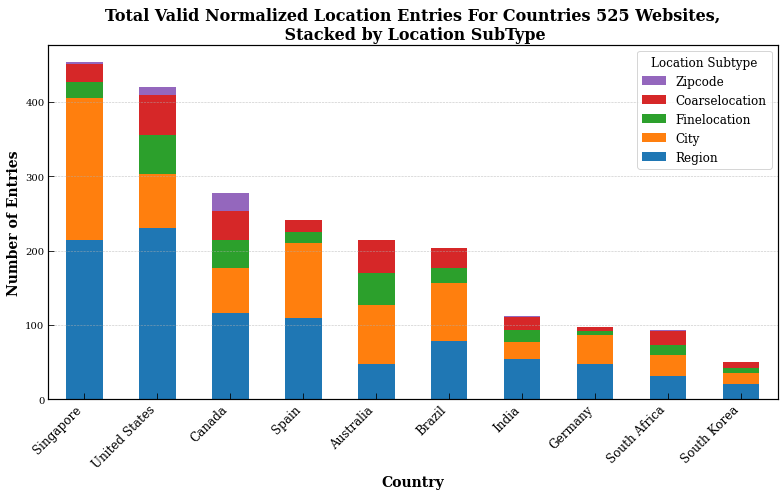

In [ ]:
# Filter global data for permission == 'Location'
df_location = df_valid[df_valid['permission'] == 'location']

# Group by [country, typ] and count the number of entries
df_location_grouped = df_location.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_location_grouped.index = pd.Series(df_location_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_location_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_location_grouped.columns = df_location_grouped.columns.str.capitalize()

# Define the desired order for location subcategories
desired_order_loc = ['Region', 'City', 'Finelocation', 'Coarselocation', 'Zipcode']
df_location_grouped = df_location_grouped.reindex(columns=desired_order_loc, fill_value=0)

# Sort countries by total count (descending)
df_location_grouped = df_location_grouped.loc[df_location_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(11, 7))

# Plot stacked bar chart
df_location_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 7),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_location_grouped.index)))
ax.set_xticklabels(df_location_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Location Entries For Countries 525 Websites,\n Stacked by Location SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Location Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


2. Stacked Bar for Monetization Subcategories

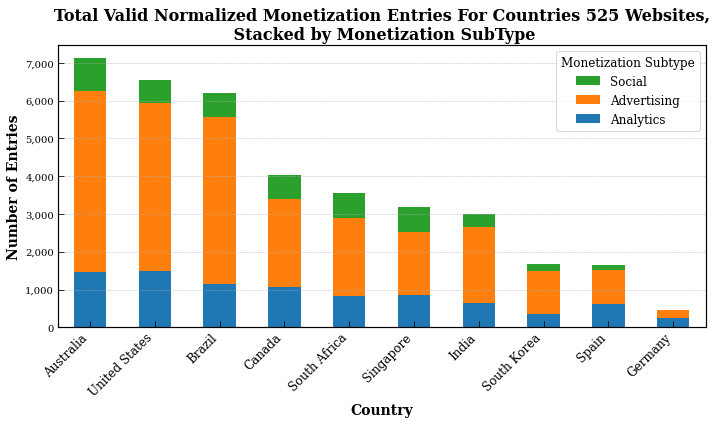

In [ ]:
# Filter valid data for permission == 'Monetization'
df_monet = df_valid[df_valid['permission'] == 'monetization']

# Group by [country, typ] and count the number of entries
df_monet_grouped = df_monet.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_monet_grouped.index = pd.Series(df_monet_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_monet_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_monet_grouped.columns = df_monet_grouped.columns.str.capitalize()

# Define the desired order for monetization subcategories
desired_order_mon = ['Analytics', 'Advertising', 'Social']
df_monet_grouped = df_monet_grouped.reindex(columns=desired_order_mon, fill_value=0)

# Sort countries by total count (descending)
df_monet_grouped = df_monet_grouped.loc[df_monet_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar chart
df_monet_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    linewidth=1.2,
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_monet_grouped.index)))
ax.set_xticklabels(df_monet_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Monetization Entries For Countries 525 Websites,\n Stacked by Monetization SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Monetization Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


3. Stacked Bar for Tracking Subcategories

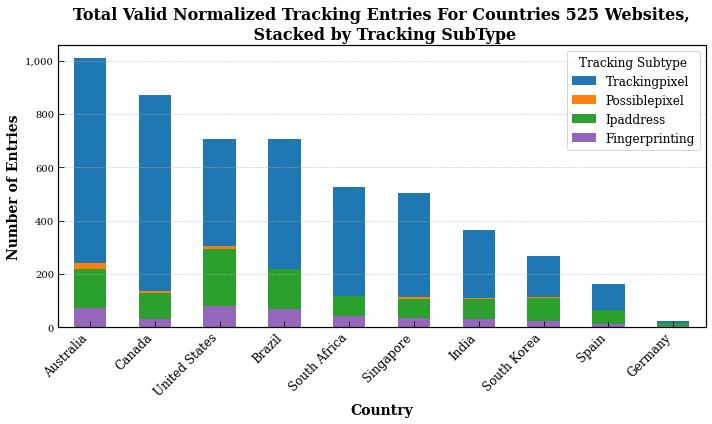

In [ ]:
# ===============================
#  Tracking Subcategories (Stacked)
# ===============================
# Filter valid data for permission == 'tracking'
df_tracking = df_valid[df_valid['permission'] == 'tracking']

# Group by [country, typ] and count the number of entries
df_tracking_grouped = df_tracking.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_tracking_grouped.index = pd.Series(df_tracking_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_tracking_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_tracking_grouped.columns = df_tracking_grouped.columns.str.capitalize()

# Define the desired order for tracking subcategories
desired_order_track = ['Fingerprinting', 'Ipaddress', 'Possiblepixel', 'Trackingpixel']
df_tracking_grouped = df_tracking_grouped.reindex(columns=desired_order_track, fill_value=0)

# Sort countries by total count (descending)
df_tracking_grouped = df_tracking_grouped.loc[df_tracking_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar chart
df_tracking_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#9467bd', '#2ca02c', '#ff7f0e', '#1f77b4'],
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_tracking_grouped.index)))
ax.set_xticklabels(df_tracking_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Tracking Entries For Countries 525 Websites,\n Stacked by Tracking SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Tracking Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()
